<a href="https://colab.research.google.com/github/angelagutierrez-dhn/Heating-Consumption-Optimisation/blob/main/Service1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas numpy matplotlib scipy

Energy threshold: 1.6285837059263664
Power threshold: 2.2915492117673817


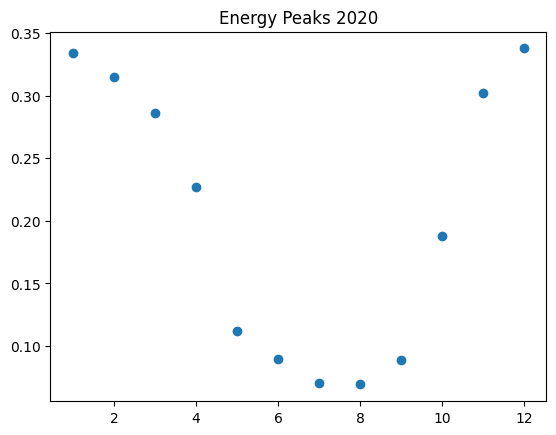

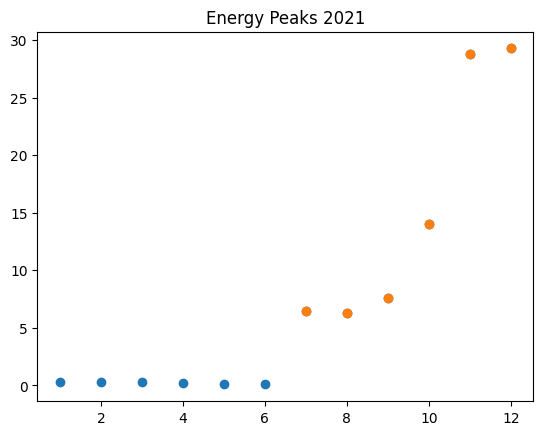

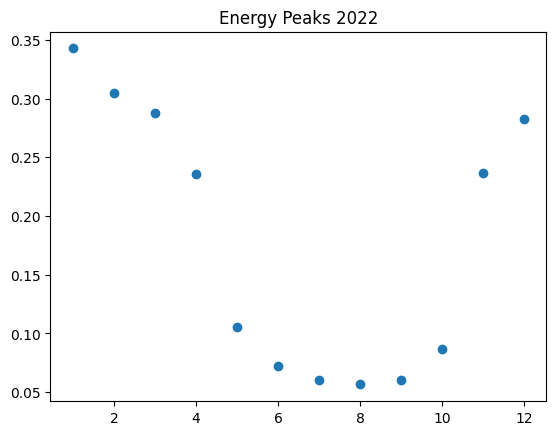

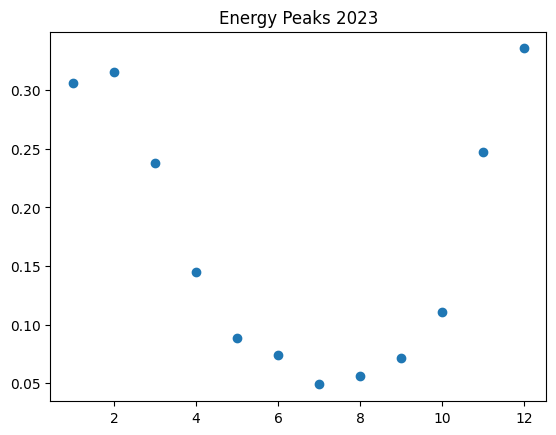

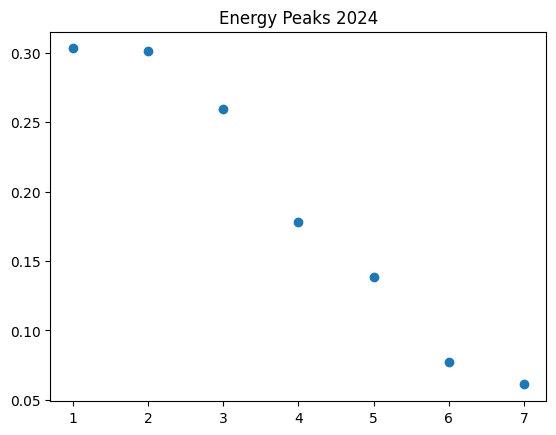

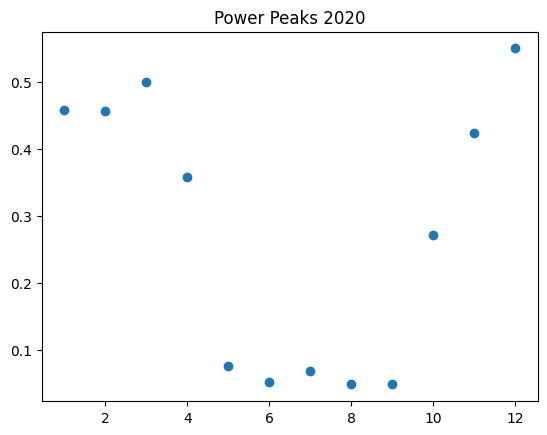

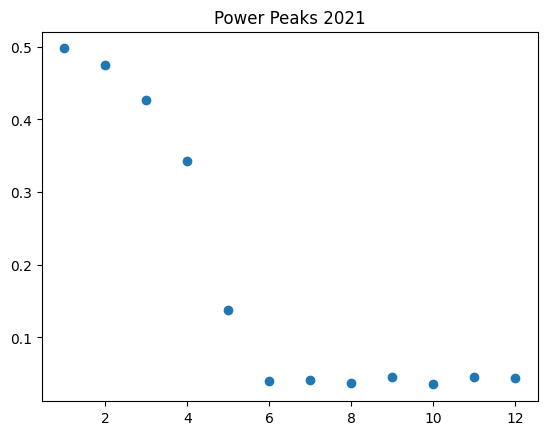

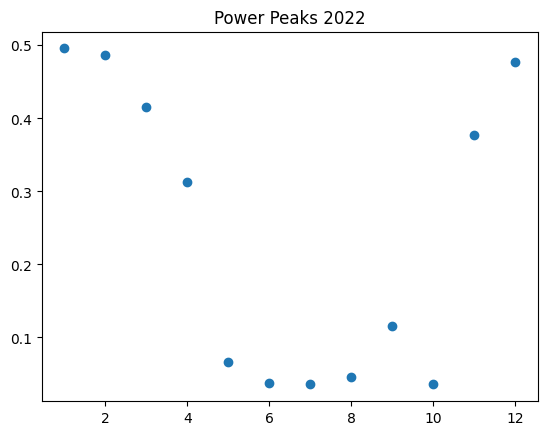

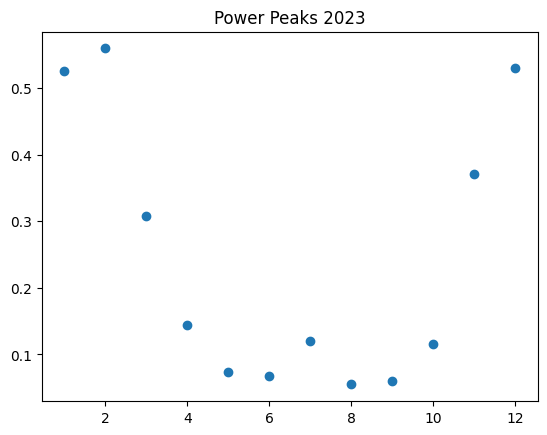

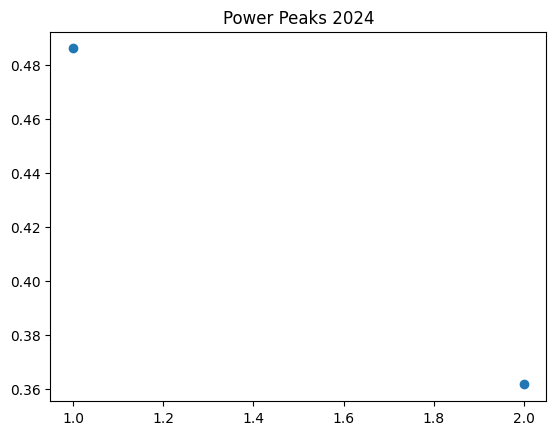

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

YEARS = [2020, 2021, 2022, 2023, 2024]

VAR_MAP = {
    "ENERGIA_F1": "Energía Contador Energía Fase 1 Central",
    "ENERGIA_F2": "Energía Contador Energía Fase 2 Central",
    "POT_GAS": "Potencia Contador Energía Calderas Gas",
    "POT_F2": "Potencia Contador Energía Fase 2"
}

def load_data():
    files = [f for f in os.listdir() if f.endswith(".csv")]
    df_list = []

    for f in files:
        df = pd.read_csv(f)
        df.columns = df.columns.str.lower().str.strip()

        df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

        df["valor"] = (
            df["valor"]
            .astype(str)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
        )
        df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

        df_list.append(df)

    df = pd.concat(df_list, ignore_index=True)
    df = df[df["fecha"].dt.year.isin(YEARS)]
    return df

df = load_data()

# ======== FILTRADO VARIABLES ========

series = {}

for key, name in VAR_MAP.items():
    temp = df[df["variable"].str.contains(name, case=False, na=False)].copy()
    temp = temp.sort_values("fecha")

    temp["value"] = temp["valor"].diff()
    temp = temp[temp["value"] >= 0]
    temp = temp.dropna()

    series[key] = temp

# ======== ENERGÍA Y POTENCIA TOTAL ========

energy = series["ENERGIA_F1"].merge(
    series["ENERGIA_F2"], on="fecha", suffixes=("_f1", "_f2")
)

energy["total"] = energy["value_f1"] + energy["value_f2"]

power = series["POT_GAS"].merge(
    series["POT_F2"], on="fecha", suffixes=("_gas", "_f2")
)

power["total"] = power["value_gas"] + power["value_f2"]

# ======== UMBRALES ========

energy_mean = energy["total"].mean()
energy_std = energy["total"].std()
energy_threshold = energy_mean + 2 * energy_std

power_mean = power["total"].mean()
power_std = power["total"].std()
power_threshold = power_mean + 2 * power_std

print("Energy threshold:", energy_threshold)
print("Power threshold:", power_threshold)

# ======== DETECCIÓN MENSUAL ========

energy["year"] = energy["fecha"].dt.year
energy["month"] = energy["fecha"].dt.month

monthly_energy = energy.groupby(["year","month"])["total"].mean().reset_index()
monthly_energy["peak"] = monthly_energy["total"] > energy_threshold

power["year"] = power["fecha"].dt.year
power["month"] = power["fecha"].dt.month

monthly_power = power.groupby(["year","month"])["total"].mean().reset_index()
monthly_power["peak"] = monthly_power["total"] > power_threshold

# ======== GRÁFICOS ========

for y in YEARS:
    e = monthly_energy[monthly_energy["year"] == y]
    plt.figure()
    plt.scatter(e["month"], e["total"])
    plt.scatter(e[e["peak"]]["month"], e[e["peak"]]["total"])
    plt.title(f"Energy Peaks {y}")
    plt.show()

for y in YEARS:
    p = monthly_power[monthly_power["year"] == y]
    plt.figure()
    plt.scatter(p["month"], p["total"])
    plt.scatter(p[p["peak"]]["month"], p[p["peak"]]["total"])
    plt.title(f"Power Peaks {y}")
    plt.show()

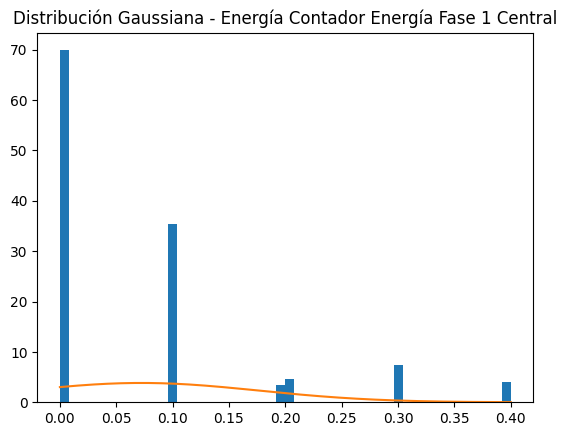

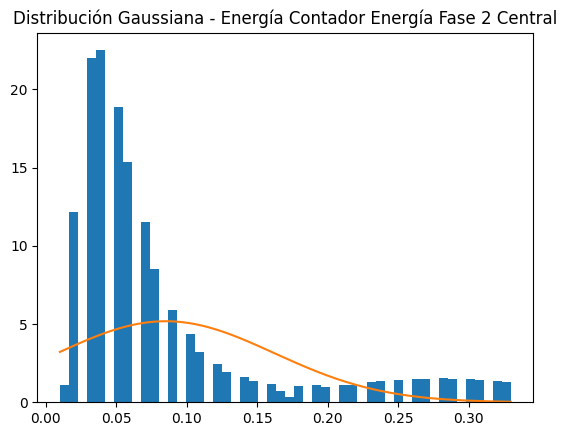

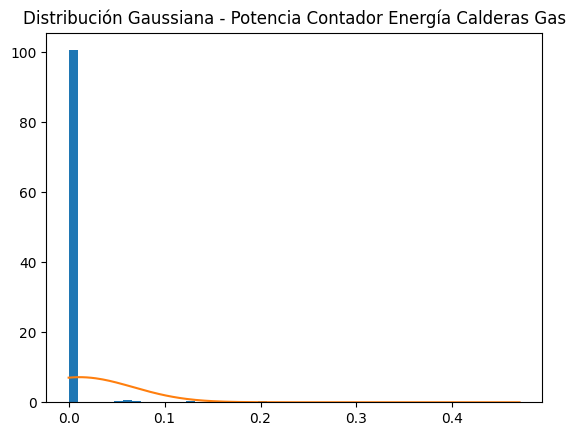

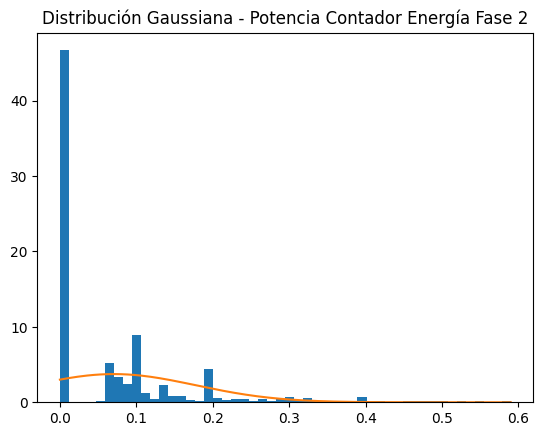

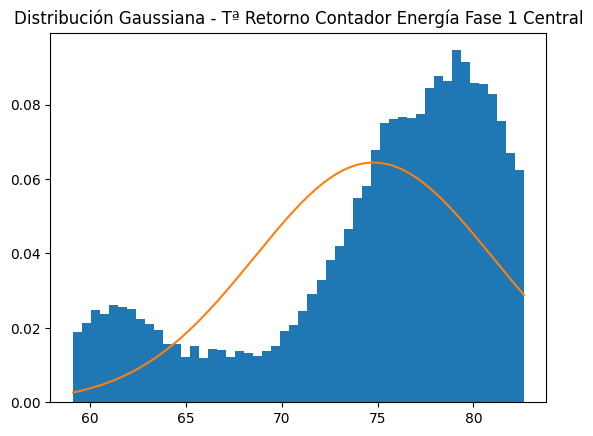

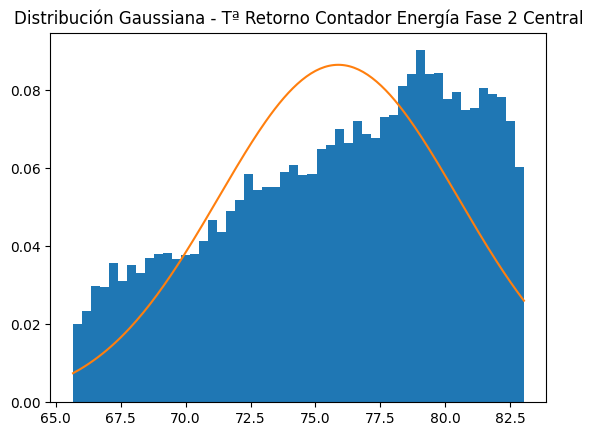

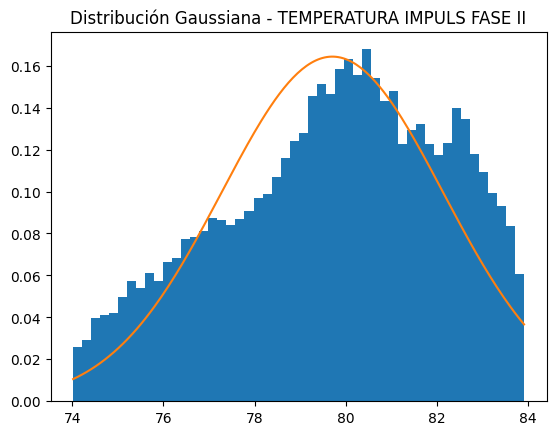

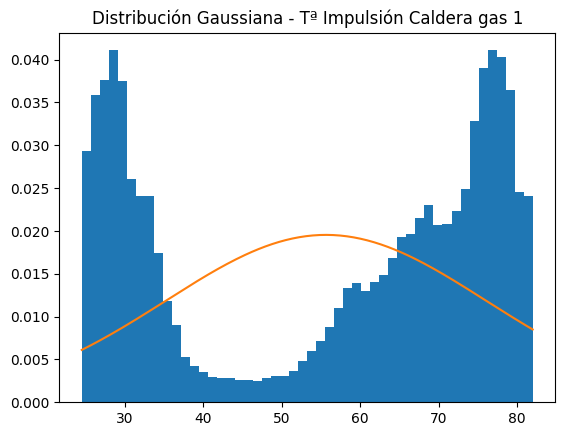

,Variable,count,mean,mode,std,min,25%,50%,75%,95%,5%,max
0,Energía Contador Energía Fase 1 Central,137470,0.072297,0.00,0.103951,0.00,0.00,0.00,0.10,0.30,0.00,0.40
1,Energía Contador Energía Fase 2 Central,129770,0.085138,0.04,0.076986,0.01,0.04,0.06,0.09,0.28,0.02,0.33
2,Potencia Contador Energía Calderas Gas,106798,0.011274,0.00,0.055619,0.00,0.00,0.00,0.00,0.06,0.00,0.47
3,Potencia Contador Energía Fase 2,78615,0.070609,0.00,0.106698,0.00,0.00,0.00,0.10,0.30,0.00,0.59
4,Tª Retorno Contador Energía Fase 1 Central,114487,74.788206,75.48,6.190707,59.13,72.26,76.47,79.42,81.85,61.32,82.63
5,Tª Retorno Contador Energía Fase 2 Central,114510,75.877367,72.30,4.609594,65.67,72.38,76.50,79.73,82.26,67.48,83.02
6,TEMPERATURA IMPULS FASE II,114375,79.705265,79.70,2.427637,74.02,77.97,79.94,81.64,83.28,75.30,83.91
7,Tª Impulsión Caldera gas 1,114411,55.647213,29.31,20.418644,24.52,31.87,63.03,74.68,79.95,26.09,81.99


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

YEARS = [2020, 2021, 2022, 2023, 2024]

VARIABLES = [
    "Energía Contador Energía Fase 1 Central",
    "Energía Contador Energía Fase 2 Central",
    "Potencia Contador Energía Calderas Gas",
    "Potencia Contador Energía Fase 2",
    "Tª Retorno Contador Energía Fase 1 Central",
    "Tª Retorno Contador Energía Fase 2 Central",
    "TEMPERATURA IMPULS FASE II",
    "Tª Impulsión Caldera gas 1"
]

ACCUMULATIVE = [
    "Energía Contador Energía Fase 1 Central",
    "Energía Contador Energía Fase 2 Central",
    "Potencia Contador Energía Calderas Gas",
    "Potencia Contador Energía Fase 2"
]

def load_data():
    files = [f for f in os.listdir() if f.endswith(".csv")]
    df_list = []
    for f in files:
        df = pd.read_csv(f)
        df.columns = df.columns.str.lower().str.strip()
        df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
        df["valor"] = (
            df["valor"]
            .astype(str)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
        )
        df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
        df_list.append(df)
    df = pd.concat(df_list, ignore_index=True)
    df = df[df["fecha"].dt.year.isin(YEARS)]
    return df

df = load_data()

results = []

for var in VARIABLES:
    temp = df[df["variable"].str.contains(var, case=False, na=False)].copy()
    temp = temp.sort_values("fecha")

    if var in ACCUMULATIVE:
        temp["value"] = temp["valor"].diff()
        temp = temp[temp["value"] >= 0]
    else:
        temp["value"] = temp["valor"]

    temp = temp.dropna()

    # limpieza percentil 95%
    q_low = temp["value"].quantile(0.05)
    q_high = temp["value"].quantile(0.95)
    temp = temp[(temp["value"] >= q_low) & (temp["value"] <= q_high)]

    series = temp["value"]

    stats = {
        "Variable": var,
        "count": series.count(),
        "mean": series.mean(),
        "mode": series.mode().iloc[0] if not series.mode().empty else np.nan,
        "std": series.std(),
        "min": series.min(),
        "25%": series.quantile(0.25),
        "50%": series.quantile(0.50),
        "75%": series.quantile(0.75),
        "95%": series.quantile(0.95),
        "5%": series.quantile(0.05),
        "max": series.max()
    }

    results.append(stats)

    # Gauss
    mu = series.mean()
    std = series.std()
    x = np.linspace(series.min(), series.max(), 200)

    plt.figure()
    plt.hist(series, bins=50, density=True)
    plt.plot(x, norm.pdf(x, mu, std))
    plt.title(f"Distribución Gaussiana - {var}")
    plt.show()

desc_table = pd.DataFrame(results)
desc_table


✅ Datos cargados: (1049002, 5)


,endpoint,id,variable,fecha,valor
0,EDEN1D - M028309 - TORRELAGO,4172,Potencia Contador Energía Fase 2 (15 minuto),2020-01-01 00:00:00,0.39
1,EDEN1D - M028309 - TORRELAGO,4172,Potencia Contador Energía Fase 2 (15 minuto),2020-01-01 00:15:00,0.23
2,EDEN1D - M028309 - TORRELAGO,4172,Potencia Contador Energía Fase 2 (15 minuto),2020-01-01 00:30:00,0.23


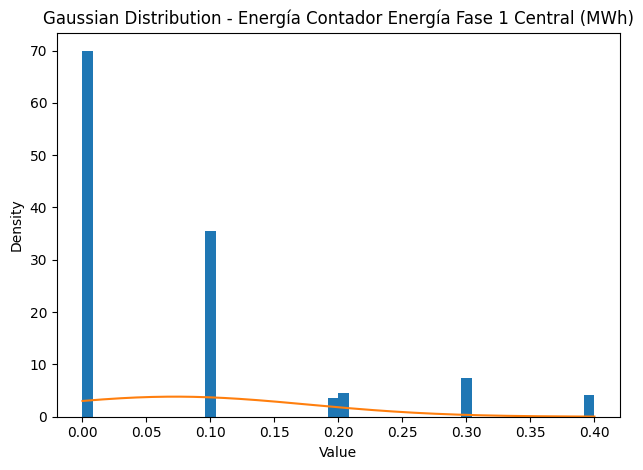

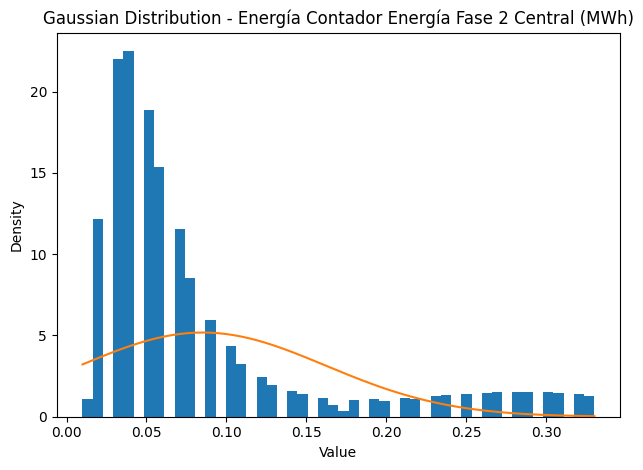

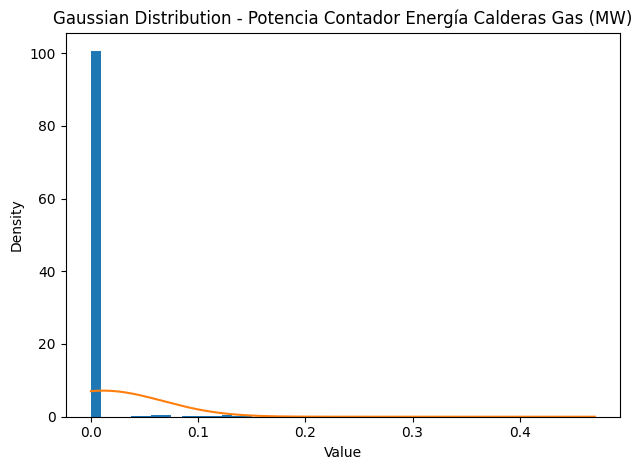

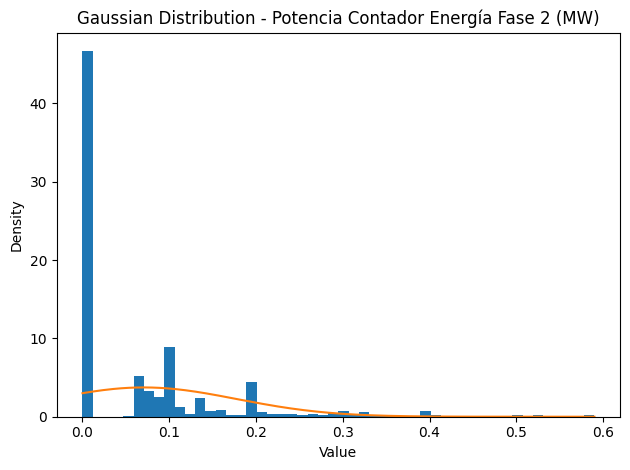

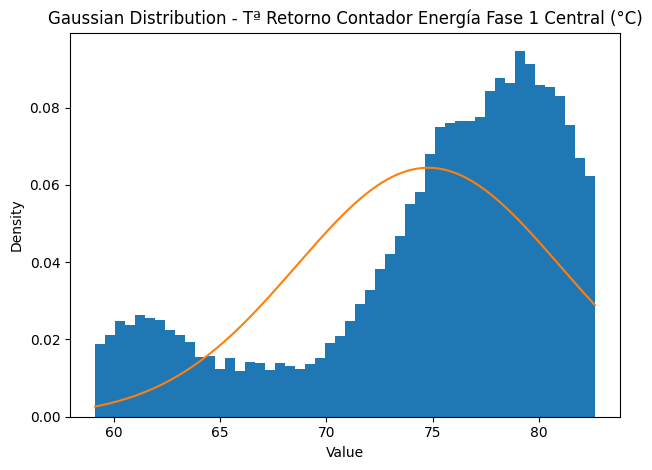

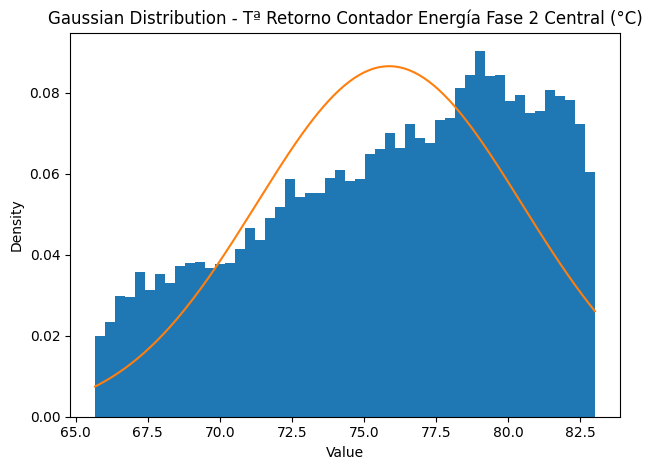

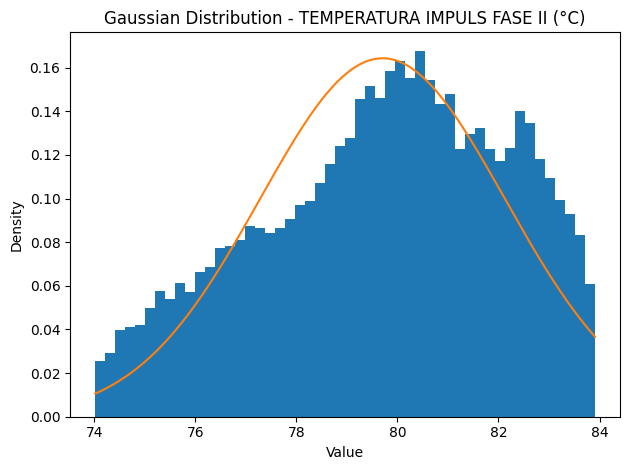

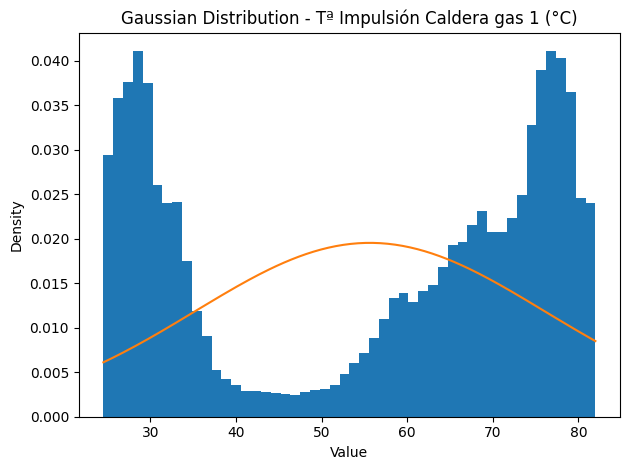


✅ TABLA DESCRIPTIVA (limpia + diff en acumulativas) — 2020-2024


,Variable,Unit,count,mean,mode,std,min,25%,50%,75%,95%,5%,max,outlier_quantile_used
0,Energía Contador Energía Fase 1 Central,MWh,137470,0.0723,0.00,0.1040,0.00,0.00,0.00,0.10,0.30,0.00,0.40,0.95
1,Energía Contador Energía Fase 2 Central,MWh,129770,0.0851,0.04,0.0770,0.01,0.04,0.06,0.09,0.28,0.02,0.33,0.95
2,Potencia Contador Energía Calderas Gas,MW,106798,0.0113,0.00,0.0556,0.00,0.00,0.00,0.00,0.06,0.00,0.47,0.95
3,Potencia Contador Energía Fase 2,MW,78615,0.0706,0.00,0.1067,0.00,0.00,0.00,0.10,0.30,0.00,0.59,0.95
4,Tª Retorno Contador Energía Fase 1 Central,°C,114487,74.7882,75.48,6.1907,59.13,72.26,76.47,79.42,81.85,61.32,82.63,0.95
5,Tª Retorno Contador Energía Fase 2 Central,°C,114510,75.8774,72.30,4.6096,65.67,72.38,76.50,79.73,82.26,67.48,83.02,0.95
6,TEMPERATURA IMPULS FASE II,°C,114375,79.7053,79.70,2.4276,74.02,77.97,79.94,81.64,83.28,75.30,83.91,0.95
7,Tª Impulsión Caldera gas 1,°C,114411,55.6472,29.31,20.4186,24.52,31.87,63.03,74.68,79.95,26.09,81.99,0.95


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from IPython.display import display

# ==============================
# CONFIG
# ==============================
YEARS = [2020, 2021, 2022, 2023, 2024]

# Variables (tal como aparecen en la columna "variable")
VARIABLES = [
    "Energía Contador Energía Fase 1 Central",
    "Energía Contador Energía Fase 2 Central",
    "Potencia Contador Energía Calderas Gas",
    "Potencia Contador Energía Fase 2",
    "Tª Retorno Contador Energía Fase 1 Central",
    "Tª Retorno Contador Energía Fase 2 Central",
    "TEMPERATURA IMPULS FASE II",
    "Tª Impulsión Caldera gas 1",
]

# Variables acumulativas (requieren diff)
ACCUMULATIVE = {
    "Energía Contador Energía Fase 1 Central",
    "Energía Contador Energía Fase 2 Central",
    "Potencia Contador Energía Calderas Gas",
    "Potencia Contador Energía Fase 2",
}

# Unidades
UNITS_MAP = {
    "Energía Contador Energía Fase 1 Central": "MWh",
    "Energía Contador Energía Fase 2 Central": "MWh",
    "Potencia Contador Energía Calderas Gas": "MW",
    "Potencia Contador Energía Fase 2": "MW",
    "Tª Retorno Contador Energía Fase 1 Central": "°C",
    "Tª Retorno Contador Energía Fase 2 Central": "°C",
    "TEMPERATURA IMPULS FASE II": "°C",
    "Tª Impulsión Caldera gas 1": "°C",
}

# Limpieza por percentil:
# - Si quieres criterio Izu: 0.95
# - Si quieres criterio Ángela (más agresivo): 0.75
# Puedes cambiar variable por variable.
OUTLIER_Q = {v: 0.95 for v in VARIABLES}  # por defecto 95% (Izu)
# Ejemplo (si quieres aplicar 75% a alguna):
# OUTLIER_Q["TEMPERATURA IMPULS FASE II"] = 0.75

# ==============================
# HELPERS
# ==============================
def load_data_from_current_dir():
    """Lee todos los CSV del directorio actual de Colab."""
    files = [f for f in os.listdir() if f.lower().endswith(".csv")]
    if not files:
        raise FileNotFoundError("No se han encontrado CSV en el directorio actual de Colab.")

    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df.columns = df.columns.str.lower().str.strip()

        required = {"endpoint", "id", "variable", "fecha", "valor"}
        if not required.issubset(df.columns):
            raise ValueError(f"El CSV {f} no tiene las columnas esperadas {required}. Encontradas: {df.columns.tolist()}")

        df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

        # Convertir coma decimal a punto (y quitar separadores de miles si los hubiera)
        df["valor"] = (
            df["valor"]
            .astype(str)
            .str.replace(".", "", regex=False)   # por si hay separador de miles
            .str.replace(",", ".", regex=False)  # coma decimal -> punto
            .str.strip()
        )
        df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
        dfs.append(df)

    big = pd.concat(dfs, ignore_index=True)
    big = big.dropna(subset=["fecha", "valor", "variable"])
    big = big[big["fecha"].dt.year.isin(YEARS)]
    return big

def clean_outliers(series: pd.Series, q: float) -> pd.Series:
    """Filtra extremos por cuantiles simétricos (1-q y q)."""
    s = series.dropna()
    if s.empty:
        return s
    hi = s.quantile(q)
    lo = s.quantile(1 - q)
    return s[(s >= lo) & (s <= hi)]

def compute_mode(series: pd.Series):
    m = series.mode(dropna=True)
    return m.iloc[0] if len(m) else np.nan

def gaussian_plot(series: pd.Series, title: str):
    s = series.dropna()
    if len(s) < 10:
        print(f"[WARN] No hay suficientes datos para Gauss: {title}")
        return

    mu = s.mean()
    sigma = s.std(ddof=1)

    plt.figure()
    plt.hist(s.values, bins=50, density=True)
    x = np.linspace(s.min(), s.max(), 200)
    if sigma and sigma > 0:
        plt.plot(x, norm.pdf(x, mu, sigma))
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

# ==============================
# RUN
# ==============================
df = load_data_from_current_dir()
print("✅ Datos cargados:", df.shape)
display(df.head(3))

results = []

for var in VARIABLES:
    # Selección robusta (por si hay espacios/variantes)
    temp = df[df["variable"].astype(str).str.contains(var, case=False, na=False)].copy()
    temp = temp.sort_values("fecha")

    if temp.empty:
        print(f"[WARN] No se encontró data para: {var}")
        continue

    # diff() para acumulativas
    if var in ACCUMULATIVE:
        temp["value"] = temp["valor"].diff()
        temp.loc[temp["value"] < 0, "value"] = np.nan  # resets
    else:
        temp["value"] = temp["valor"]

    temp = temp.dropna(subset=["value"])

    # limpieza outliers
    q = OUTLIER_Q.get(var, 0.95)
    cleaned = clean_outliers(temp["value"], q=q)
    temp = temp.loc[cleaned.index]

    s = temp["value"].dropna()
    if s.empty:
        print(f"[WARN] Serie vacía tras limpieza: {var}")
        continue

    stats = {
        "Variable": var,
        "Unit": UNITS_MAP.get(var, ""),
        "count": int(s.count()),
        "mean": float(s.mean()),
        "mode": float(compute_mode(s)),
        "std": float(s.std(ddof=1)),
        "min": float(s.min()),
        "25%": float(s.quantile(0.25)),
        "50%": float(s.quantile(0.50)),
        "75%": float(s.quantile(0.75)),
        "95%": float(s.quantile(0.95)),
        "5%": float(s.quantile(0.05)),
        "max": float(s.max()),
        "outlier_quantile_used": q,
    }
    results.append(stats)

    # Gauss plot por variable
    gaussian_plot(s, title=f"Gaussian Distribution - {var} ({UNITS_MAP.get(var,'')})")

# Tabla final
desc_table = pd.DataFrame(results)

# Orden de columnas (como en tu doc + unidad)
desc_table = desc_table[
    ["Variable", "Unit", "count", "mean", "mode", "std", "min",
     "25%", "50%", "75%", "95%", "5%", "max", "outlier_quantile_used"]
]

# (Opcional) redondeo para ver mejor por pantalla:
desc_table_display = desc_table.copy()
for col in ["mean","mode","std","min","25%","50%","75%","95%","5%","max"]:
    desc_table_display[col] = desc_table_display[col].round(4)

print("\n✅ TABLA DESCRIPTIVA (limpia + diff en acumulativas) — 2020-2024")
display(desc_table_display)

In [7]:
energy_f1 = df[df["variable"].str.contains("Fase 1 Central", case=False)]
energy_f2 = df[df["variable"].str.contains("Fase 2 Central", case=False)]

energy_f1["val"] = energy_f1["valor"].diff()
energy_f2["val"] = energy_f2["valor"].diff()

energy = energy_f1.merge(energy_f2, on="fecha", suffixes=("_f1","_f2"))
energy["total"] = energy["val_f1"] + energy["val_f2"]

power_gas = df[df["variable"].str.contains("Calderas Gas", case=False)]
power_f2 = df[df["variable"].str.contains("Potencia Contador Energía Fase 2", case=False)]

power_gas["val"] = power_gas["valor"].diff()
power_f2["val"] = power_f2["valor"].diff()

power = power_gas.merge(power_f2, on="fecha", suffixes=("_gas","_f2"))
power["total"] = power["val_gas"] + power["val_f2"]

annual = []

for y in YEARS:
    e = energy[energy["fecha"].dt.year == y]["total"].mean()
    p = power[power["fecha"].dt.year == y]["total"].mean()

    annual.append({
        "Año": y,
        "Energía Total Media (MWh)": e,
        "Potencia Total Media (MW)": p
    })

annual_df = pd.DataFrame(annual)
annual_df["Variación Energía (%)"] = annual_df["Energía Total Media (MWh)"].pct_change()*100
annual_df["Variación Potencia (%)"] = annual_df["Potencia Total Media (MW)"].pct_change()*100

annual_df

/tmp/ipython-input-312/2060193615.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  energy_f1["val"] = energy_f1["valor"].diff()
/tmp/ipython-input-312/2060193615.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  energy_f2["val"] = energy_f2["valor"].diff()
/tmp/ipython-input-312/2060193615.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

,Año,Energía Total Media (MWh),Potencia Total Media (MW),Variación Energía (%),Variación Potencia (%)
0,2020,-0.359298,-0.000001,NaN,NaN
1,2021,0.190791,-0.000011,-153.100979,700.341686
2,2022,0.088368,0.000006,-53.683128,-150.114155
3,2023,0.084351,-0.000002,-4.546211,-140.166213
4,2024,0.153051,-0.000045,81.445719,1876.381966
